In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\Week 6\sales_data.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataframe
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [3]:
# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract month for monthly analysis
df['Month'] = df['Date'].dt.month_name()

# Verify the changes
print("DataFrame Info after date conversion and month extraction:")
df.info()
print("\nFirst 5 rows after date conversion and month extraction:")
display(df.head())

DataFrame Info after date conversion and month extraction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
 7   Month        100 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 6.4+ KB

First 5 rows after date conversion and month extraction:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month
0,2024-01-01,Phone,7,37300,CUST001,East,261100,January
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,January
2,2024-01-03,Phone,2,21746,CUST003,West,43492,January
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,January
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,January


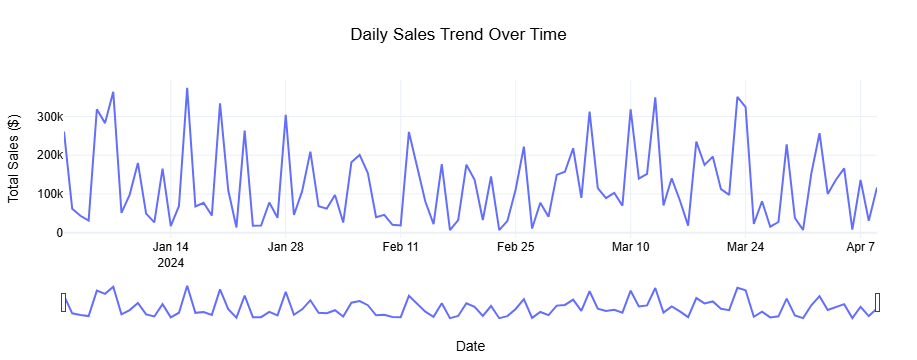

In [4]:
# Group by Date and sum Total_Sales to get daily sales
daily_sales = df.groupby('Date')['Total_Sales'].sum().reset_index()

# Create an interactive line chart using Plotly Express
fig_sales_trend = px.line(
    daily_sales,
    x='Date',
    y='Total_Sales',
    title='Daily Sales Trend Over Time',
    labels={'Date': 'Date', 'Total_Sales': 'Total Sales ($)'},
    template='plotly_white'
)

# Customize layout for better readability
fig_sales_trend.update_xaxes(rangeslider_visible=True)
fig_sales_trend.update_layout(
    hovermode='x unified',
    title_x=0.5,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    font=dict(family="Arial", size=12, color="black"),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig_sales_trend.show()

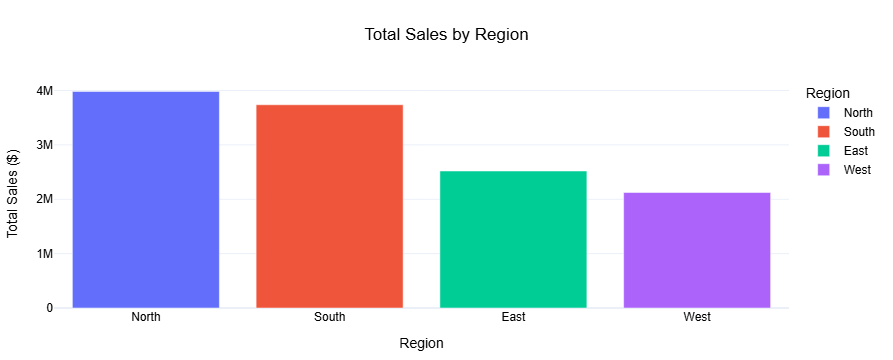

In [5]:
# Group by Region and sum Total_Sales
regional_sales = df.groupby('Region')['Total_Sales'].sum().reset_index()

# Sort for better visualization
regional_sales = regional_sales.sort_values(by='Total_Sales', ascending=False)

# Create an interactive bar chart using Plotly Express
fig_regional_sales = px.bar(
    regional_sales,
    x='Region',
    y='Total_Sales',
    title='Total Sales by Region',
    labels={'Region': 'Region', 'Total_Sales': 'Total Sales ($)'},
    template='plotly_white',
    color='Region' # Assign different colors to each region
)

# Customize layout for better readability
fig_regional_sales.update_layout(
    title_x=0.5,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    font=dict(family="Arial", size=12, color="black"),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig_regional_sales.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_19312\1232410819.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




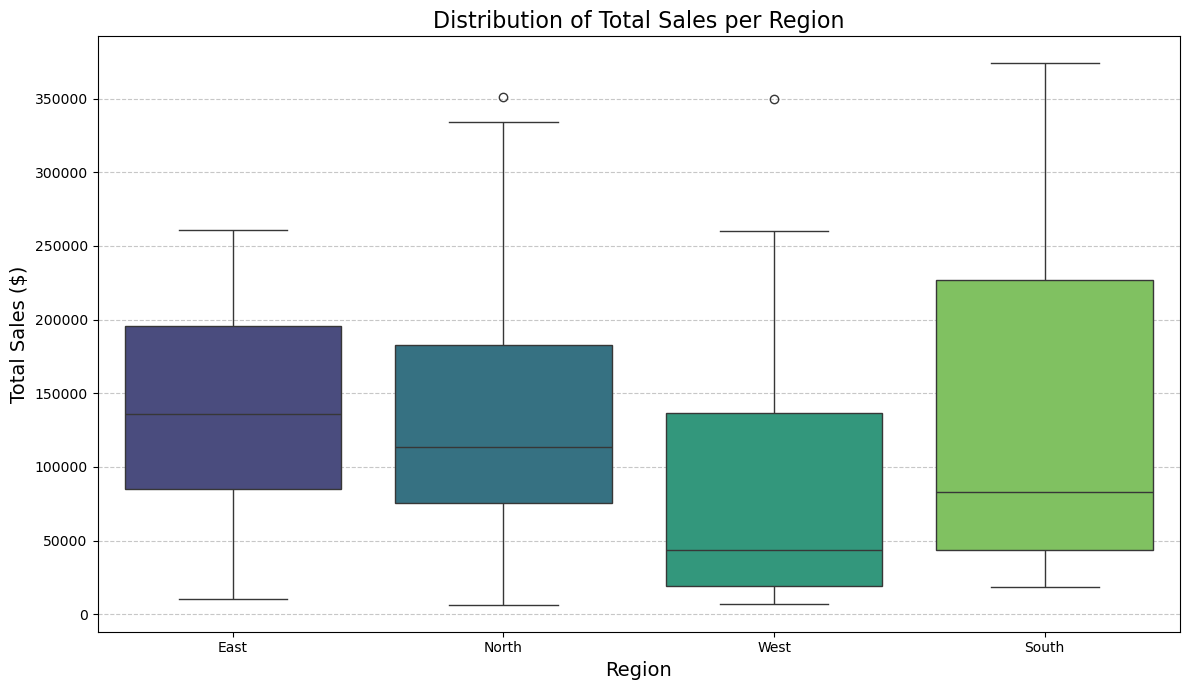

In [10]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Region', y='Total_Sales', data=df, palette='viridis')
plt.title('Distribution of Total Sales per Region', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Total Sales ($)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

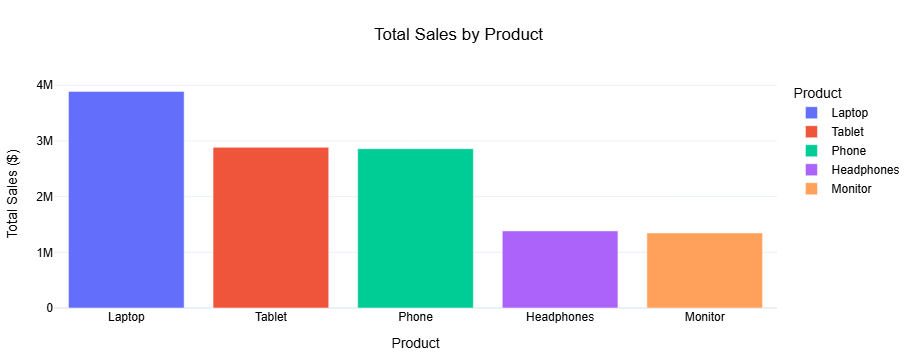

In [6]:
# Group by Product and sum Total_Sales
product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

# Sort for better visualization
product_sales = product_sales.sort_values(by='Total_Sales', ascending=False)

# Create an interactive bar chart using Plotly Express
fig_product_sales = px.bar(
    product_sales,
    x='Product',
    y='Total_Sales',
    title='Total Sales by Product',
    labels={'Product': 'Product', 'Total_Sales': 'Total Sales ($)'},
    template='plotly_white',
    color='Product' # Assign different colors to each product
)

# Customize layout for better readability
fig_product_sales.update_layout(
    title_x=0.5,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    font=dict(family="Arial", size=12, color="black"),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig_product_sales.show()

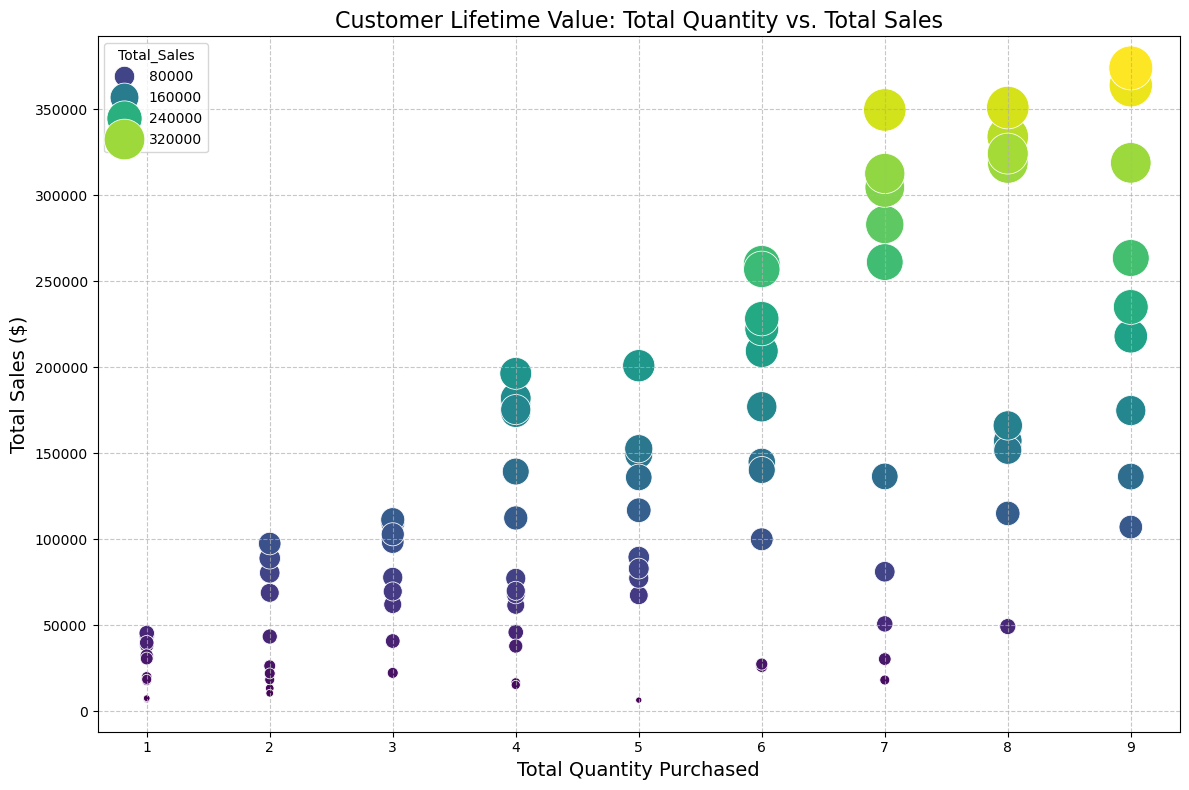

In [7]:
# Group by Customer_ID to calculate total quantity and total sales per customer
customer_cltv = df.groupby('Customer_ID').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Total_Sales', 'sum')
).reset_index()

# Create a scatter plot using Seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=customer_cltv,
    x='Total_Quantity',
    y='Total_Sales',
    hue='Total_Sales', # Color points by Total Sales
    size='Total_Sales', # Size points by Total Sales
    sizes=(20, 1000), # Define the range of sizes
    palette='viridis' # Choose a color palette
    # Removed legend='full' to resolve tight layout warning, Seaborn will generate a color bar by default for continuous hue
)

plt.title('Customer Lifetime Value: Total Quantity vs. Total Sales', fontsize=16)
plt.xlabel('Total Quantity Purchased', fontsize=14)
plt.ylabel('Total Sales ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

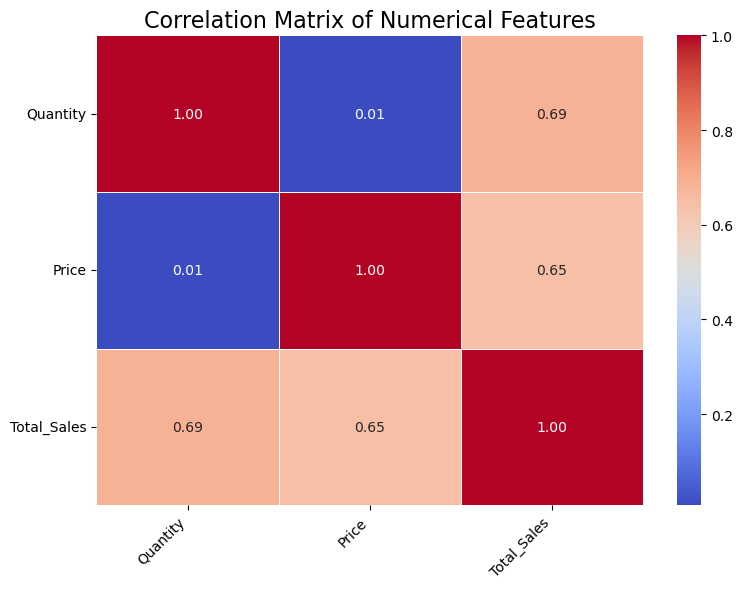

In [8]:
# Select numerical columns for correlation analysis
numerical_cols = ['Quantity', 'Price', 'Total_Sales']
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True, # Show the correlation values on the heatmap
    cmap='coolwarm', # Color map for positive and negative correlations
    fmt='.2f', # Format annotations to two decimal places
    linewidths=.5 # Add lines between cells
)

plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Average Total Sales per Region:


,Region,Total_Sales
1,North,142272.678571
2,South,138438.962963
0,East,132612.578947
3,West,81689.307692


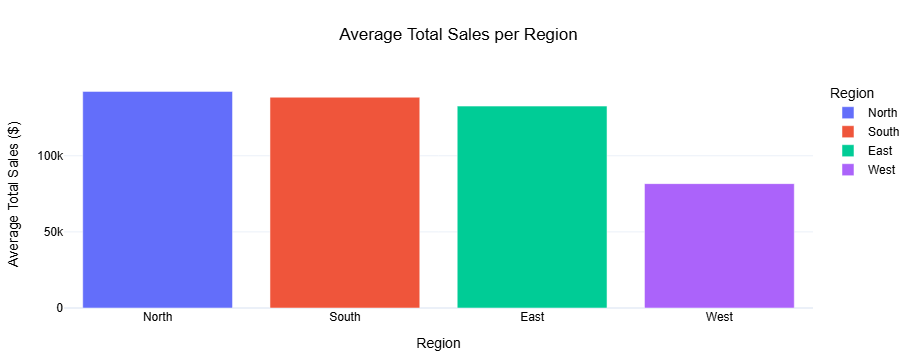

In [9]:
# Calculate the average total sales per region
average_sales_per_region = df.groupby('Region')['Total_Sales'].mean().reset_index()

# Sort for better readability
average_sales_per_region = average_sales_per_region.sort_values(by='Total_Sales', ascending=False)

print("Average Total Sales per Region:")
display(average_sales_per_region)

# Optionally, visualize this with a bar chart
fig_avg_sales_region = px.bar(
    average_sales_per_region,
    x='Region',
    y='Total_Sales',
    title='Average Total Sales per Region',
    labels={'Region': 'Region', 'Total_Sales': 'Average Total Sales ($)'},
    template='plotly_white',
    color='Region'
)

fig_avg_sales_region.update_layout(
    title_x=0.5,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    font=dict(family="Arial", size=12, color="black"),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig_avg_sales_region.show()

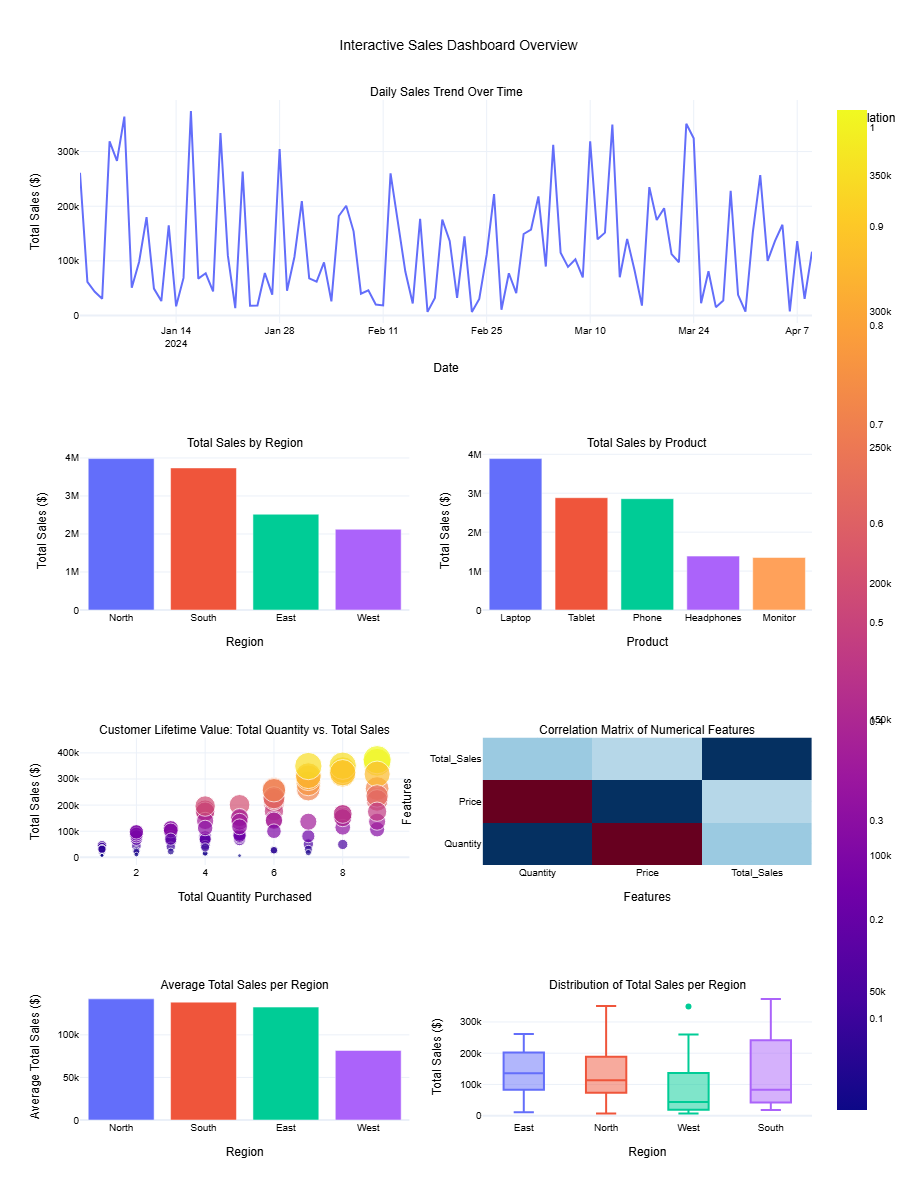

In [11]:
from plotly.subplots import make_subplots

# Recreate Plotly version of CLTV scatter plot
fig_cltv_plotly = px.scatter(
    customer_cltv,
    x='Total_Quantity',
    y='Total_Sales',
    color='Total_Sales', # Color points by Total Sales
    size='Total_Sales', # Size points by Total Sales
    title='Customer Lifetime Value: Total Quantity vs. Total Sales',
    labels={'Total_Quantity': 'Total Quantity Purchased', 'Total_Sales': 'Total Sales ($)'},
    template='plotly_white'
)
fig_cltv_plotly.update_layout(title_x=0.5)

# Recreate Plotly version of Correlation Heatmap
fig_correlation_heatmap_plotly = go.Figure(data=go.Heatmap(
                   z=correlation_matrix.values,
                   x=correlation_matrix.columns,
                   y=correlation_matrix.index,
                   colorscale='RdBu', # Changed 'Coolwarm' to 'RdBu'
                   colorbar=dict(title='Correlation')),
                   layout=go.Layout(title='Correlation Matrix of Numerical Features',
                                    xaxis_title='Features',
                                    yaxis_title='Features'))
fig_correlation_heatmap_plotly.update_layout(title_x=0.5)

# Recreate Plotly version of Distribution of Total Sales per Region Box Plot
fig_sales_distribution_region_plotly = px.box(
    df,
    x='Region',
    y='Total_Sales',
    color='Region',
    title='Distribution of Total Sales per Region',
    labels={'Region': 'Region', 'Total_Sales': 'Total Sales ($)'},
    template='plotly_white'
)
fig_sales_distribution_region_plotly.update_layout(title_x=0.5)


# Create subplots for the dashboard (4 rows, 2 columns)
# The sales trend will span across 2 columns in the first row.
dashboard = make_subplots(
    rows=4, cols=2,
    row_heights=[0.35, 0.25, 0.20, 0.20],
    specs=[[
        {"colspan": 2},
        None
    ],
    [{}, {}],
    [{}, {}],
    [{}, {}]],
    subplot_titles=[
        "Daily Sales Trend Over Time",
        "Total Sales by Region",
        "Total Sales by Product",
        "Customer Lifetime Value: Total Quantity vs. Total Sales",
        "Correlation Matrix of Numerical Features",
        "Average Total Sales per Region",
        "Distribution of Total Sales per Region"
    ]
)

# Add traces from existing Plotly figures to the dashboard
# 1. Daily Sales Trend
for trace in fig_sales_trend.data:
    dashboard.add_trace(trace, row=1, col=1)

# 2. Total Sales by Region
for trace in fig_regional_sales.data:
    dashboard.add_trace(trace, row=2, col=1)

# 3. Total Sales by Product
for trace in fig_product_sales.data:
    dashboard.add_trace(trace, row=2, col=2)

# 4. Customer Lifetime Value (Plotly version)
for trace in fig_cltv_plotly.data:
    dashboard.add_trace(trace, row=3, col=1)

# 5. Correlation Matrix (Plotly version)
for trace in fig_correlation_heatmap_plotly.data:
    dashboard.add_trace(trace, row=3, col=2)

# 6. Average Total Sales per Region
for trace in fig_avg_sales_region.data:
    dashboard.add_trace(trace, row=4, col=1)

# 7. Distribution of Total Sales per Region (Plotly version)
for trace in fig_sales_distribution_region_plotly.data:
    dashboard.add_trace(trace, row=4, col=2)


# Update layout for the entire dashboard
dashboard.update_layout(
    title_text="Interactive Sales Dashboard Overview",
    height=1200,
    showlegend=False, # Often better to manage legends within individual subplots if needed
    template='plotly_white',
    title_x=0.5,
    font=dict(family="Arial", size=10, color="black")
)

# Adjust subplot titles font size
for i in dashboard['layout']['annotations']:
    i['font']['size'] = 12

# Update axis labels and range selectors for each subplot where necessary
dashboard.update_xaxes(rangeslider_visible=False, row=1, col=1) # Remove range slider for daily sales to avoid clutter in dashboard
dashboard.update_xaxes(title_text='Date', row=1, col=1)
dashboard.update_yaxes(title_text='Total Sales ($)', row=1, col=1)

dashboard.update_xaxes(title_text='Region', row=2, col=1)
dashboard.update_yaxes(title_text='Total Sales ($)', row=2, col=1)

dashboard.update_xaxes(title_text='Product', row=2, col=2)
dashboard.update_yaxes(title_text='Total Sales ($)', row=2, col=2)

dashboard.update_xaxes(title_text='Total Quantity Purchased', row=3, col=1)
dashboard.update_yaxes(title_text='Total Sales ($)', row=3, col=1)

dashboard.update_xaxes(title_text='Features', row=3, col=2)
dashboard.update_yaxes(title_text='Features', row=3, col=2)

dashboard.update_xaxes(title_text='Region', row=4, col=1)
dashboard.update_yaxes(title_text='Average Total Sales ($)', row=4, col=1)

dashboard.update_xaxes(title_text='Region', row=4, col=2)
dashboard.update_yaxes(title_text='Total Sales ($)', row=4, col=2)

dashboard.show()